##1. Imports

In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor']   = '#1a1d27'
plt.rcParams['axes.edgecolor']   = '#2a2d3a'
plt.rcParams['text.color']       = '#e8eaf6'
plt.rcParams['axes.labelcolor']  = '#e8eaf6'
plt.rcParams['xtick.color']      = '#e8eaf6'
plt.rcParams['ytick.color']      = '#e8eaf6'
plt.rcParams['grid.color']       = '#2a2d3a'
plt.rcParams['figure.dpi']       = 110

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


##2. Data integration

In [281]:
df1=pd.read_csv("../Dataset/Raw/Indian_housing_Delhi_data.csv")
df2=pd.read_csv("../Dataset/Raw/Indian_housing_Mumbai_data.csv")
df3=pd.read_csv("../Dataset/Raw/Indian_housing_Pune_data.csv")

In [282]:
df = pd.concat([df1, df2, df3], ignore_index=True)

In [283]:
df.shape

(13910, 16)

In [284]:
print("\n=== BASIC STATISTICS ===")
print(df.describe(include='all'))

print("\n=== MISSING VALUES ===")
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== CATEGORICAL VALUES ===")
for col in df.select_dtypes(include=['object']):
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(df[col].value_counts().head(5))


=== BASIC STATISTICS ===
              house_type   house_size location   city      latitude  \
count              13910        13910    13910  13910  13910.000000   
unique                34         1102      702      4           NaN   
top     2 BHK Apartment   5,896 sq ft  Wagholi  Delhi           NaN   
freq                4385          664      743   5000           NaN   
mean                 NaN          NaN      NaN    NaN     22.380579   
std                  NaN          NaN      NaN    NaN      4.660315   
min                  NaN          NaN      NaN    NaN     17.468220   
25%                  NaN          NaN      NaN    NaN     18.611296   
50%                  NaN          NaN      NaN    NaN     19.148081   
75%                  NaN          NaN      NaN    NaN     28.553211   
max                  NaN          NaN      NaN    NaN     31.106586   

           longitude         price currency  numBathrooms  numBalconies  \
count   13910.000000  1.391000e+04    13910  1

In [285]:
df.head()

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
0,1 RK Studio Apartment,400 sq ft,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,NaN,NaN,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",No Deposit,Furnished
1,1 RK Studio Apartment,400 sq ft,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,NaN,NaN,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,No Deposit,Furnished
2,2 BHK Independent Floor,500 sq ft,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,NaN,NaN,NaN,Posted 12 days ago,"Zero Brokerage.\n\n2 Room set, Govt bijali Met...",No Deposit,Semi-Furnished
3,3 BHK Independent House,"1,020 sq ft",Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,NaN,NaN,NaN,Posted a year ago,Itâs a 3 bhk independent house situated in M...,No Deposit,Furnished
4,2 BHK Apartment,810 sq ft,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Unfurnished


##3. Data Preparation

In [286]:
df['Size_split'] = df['house_size'].str.split().str[0]
df['Size_split'] = df['Size_split'].str.replace(',', '', regex=False).astype(int)

df.rename(columns={'Size_split': 'Size_ft²'}, inplace=True)

In [287]:
df['price_inr'] = df['price'].round()

df.drop(columns=['currency','price','house_size','priceSqFt'], inplace=True)

In [288]:
df['Price_per_sqft'] = df['price_inr'] / df['Size_ft²']
df['Price_per_sqft'] = df['Price_per_sqft'].round(1)

In [289]:
df['numBalconies'] = df['numBalconies'].fillna(0).astype(int)

In [290]:
df['SecurityDeposit'] = df['SecurityDeposit'].str.replace(',', '', regex=False)
df['SecurityDeposit'] = df['SecurityDeposit'].str.strip().replace('No Deposit', '0', regex=False).astype(int)

df['SecurityDeposit'] = df['SecurityDeposit'].round()

In [291]:
df['isNegotiable'] = df['isNegotiable'].fillna(0)

df['isNegotiable'] = df['isNegotiable'].replace('Negotiable', 1).astype(int)

In [292]:
# Create separate label encoders
le_status = LabelEncoder()
le_city = LabelEncoder()

# Encode each column with its own encoder
df['Status'] = le_status.fit_transform(df['Status'])
df['city'] = le_city.fit_transform(df['city'])

In [293]:
df['BHK_type'] = df['house_type'].str.split().str[1]
df['BHK'] = df['BHK_type'].map({'RK': 0, 'BHK': 1})
df['rooms_num'] = df['house_type'].str.split().str[0].astype(int)

df.drop(columns=['BHK_type'], inplace=True)

In [294]:
df['property_type'] = df['house_type'].str.split().apply(lambda x: ' '.join(x[2:4]))
df['property_type'].value_counts()
df.drop(columns=['house_type'], inplace=True)

In [295]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   location          13910 non-null  object 
 1   city              13910 non-null  int64  
 2   latitude          13910 non-null  float64
 3   longitude         13910 non-null  float64
 4   numBathrooms      13854 non-null  float64
 5   numBalconies      13910 non-null  int64  
 6   isNegotiable      13910 non-null  int64  
 7   verificationDate  13910 non-null  object 
 8   description       13079 non-null  object 
 9   SecurityDeposit   13910 non-null  int64  
 10  Status            13910 non-null  int64  
 11  Size_ft²          13910 non-null  int64  
 12  price_inr         13910 non-null  int64  
 13  Price_per_sqft    13910 non-null  float64
 14  BHK               13910 non-null  int64  
 15  rooms_num         13910 non-null  int64  
 16  property_type     13910 non-null  object

In [296]:
le_property = LabelEncoder()
df['property_type'] = le_property.fit_transform(df['property_type'])

# Encode location
le_location = LabelEncoder()
df['location'] = le_location.fit_transform(df['location'])

# Fill missing values in numBathrooms with median
df['numBathrooms'] = df['numBathrooms'].fillna(df['numBathrooms'].median())

# Helper function to safely transform location
def safe_transform_location(location_name):
    try:
        return le_location.transform([location_name])[0]
    except ValueError:
        # If location not seen during training, use most common location
        return le_location.transform([df['location'].mode()[0]])[0]

In [297]:
def convert_to_days(time_str):

    time_part = time_str.replace('Posted ', '').replace(' ago', '')

    parts = time_part.split()

    if parts[0] == 'a' or parts[0] == 'an':
        value = 1
        unit = parts[1]
    else:
        value = int(parts[0])
        unit = parts[1]


    if unit == 'minute' or unit == 'minutes':
        return value / (24 * 60)
    elif unit == 'hour' or unit == 'hours':
        return value / 24
    elif unit == 'day' or unit == 'days':
        return value
    elif unit == 'month' or unit == 'months':
        return value * 30
    elif unit == 'year' or unit == 'years':
        return value * 365
    else:
        return np.nan


df['verification_days'] = df['verificationDate'].apply(convert_to_days)
data = np.array(df['verification_days'])

df.drop(columns=['description', 'verificationDate'], inplace=True)

In [298]:
df

,location,city,latitude,longitude,numBathrooms,numBalconies,isNegotiable,SecurityDeposit,Status,Size_ft²,price_inr,Price_per_sqft,BHK,rooms_num,property_type,verification_days
0,239,0,28.545561,77.254349,1.0,0,0,0,0,400,22000,55.0,0,1,3,1.0
1,340,0,28.643259,77.132828,1.0,0,0,0,0,400,20000,50.0,0,1,3,9.0
2,622,0,28.618677,77.053352,1.0,0,0,0,1,500,8500,17.0,1,2,1,12.0
3,356,0,28.712898,77.180000,3.0,0,0,0,0,1020,48000,47.1,1,3,2,365.0
4,508,0,28.723539,77.131424,2.0,0,0,0,2,810,20000,24.7,1,2,0,365.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13905,663,3,18.603699,73.761238,1.0,0,0,36000,2,655,12500,19.1,1,1,0,1095.0
13906,428,3,18.594870,73.798187,2.0,0,0,50000,2,920,16000,17.4,1,2,0,1095.0
13907,428,3,18.595701,73.797890,1.0,1,0,35000,0,650,16000,24.6,1,1,0,1095.0
13908,428,3,18.592476,73.798538,2.0,0,0,60000,0,1200,20000,16.7,1,2,0,1095.0


##4. Feature Discovery for modeling.

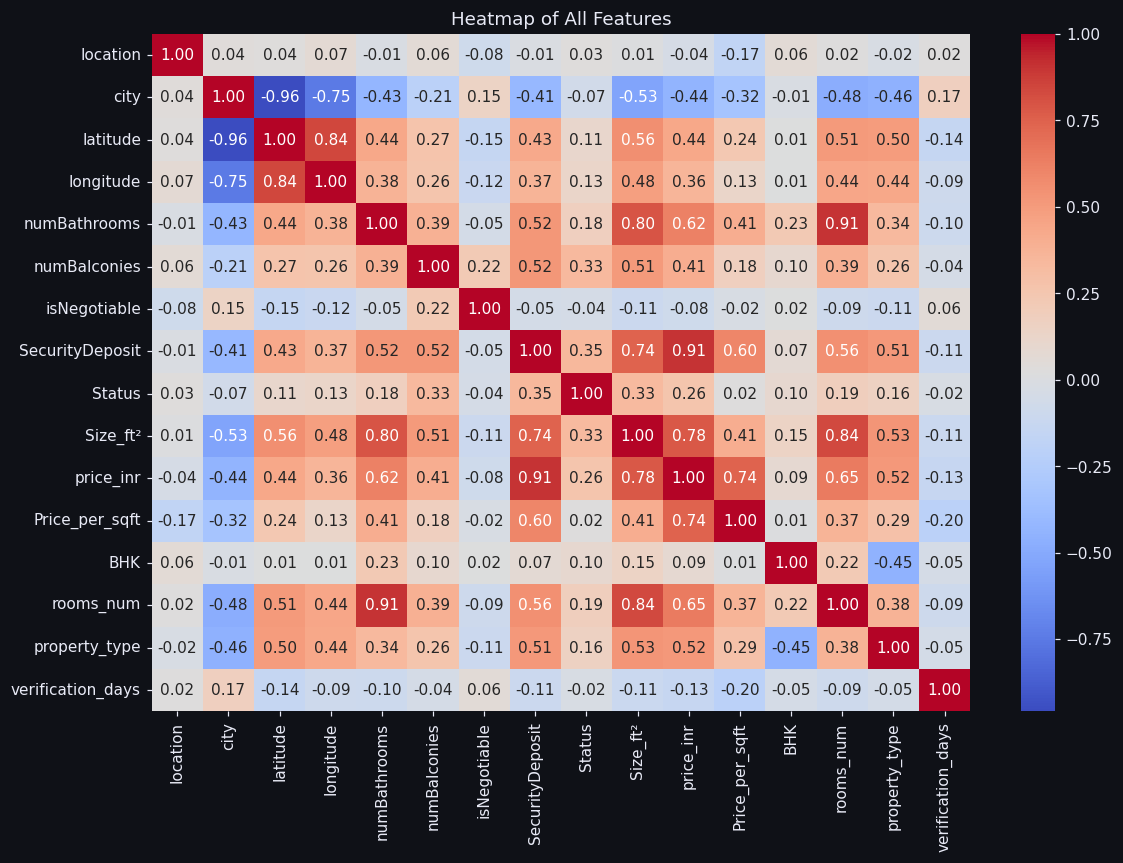

In [299]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap of All Features")
plt.show()

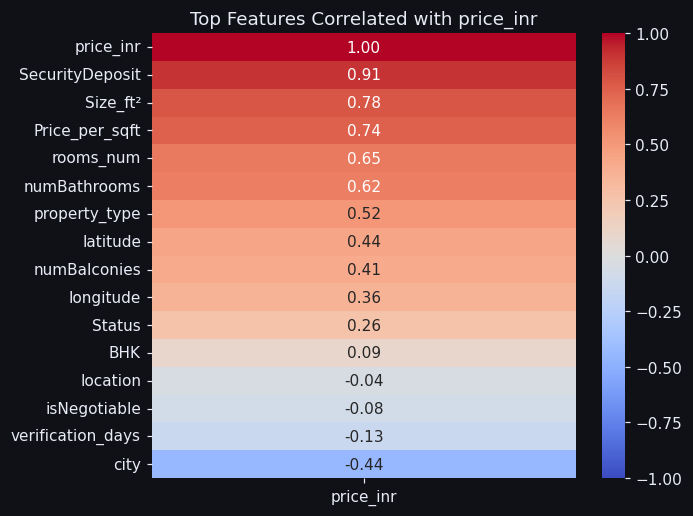

In [300]:
corr = df.corr(numeric_only=True)[['price_inr']].sort_values(by='price_inr', ascending=False)

sns.heatmap(corr.head(22),
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            fmt=".2f")

plt.title("Top Features Correlated with price_inr")
plt.tight_layout()
plt.show()

##5. Data Splitting (Train, Test).

In [301]:
X = df.drop(columns=['price_inr'])
y = df['price_inr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##6. Feature Scaling

In [302]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit only on train!
X_test_scaled  = scaler.transform(X_test)         # transform test with same params

print(f'X_train shape (scaled): {X_train_scaled.shape}')
print(f'X_test  shape (scaled): {X_test_scaled.shape}')
print('\nFeature min (after scaling):', X_train_scaled.min(axis=0).round(2))
print('Feature max (after scaling):', X_train_scaled.max(axis=0).round(2))

X_train shape (scaled): (11128, 15)
X_test  shape (scaled): (2782, 15)

Feature min (after scaling): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Feature max (after scaling): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


#7. Model Training

In [303]:
# ── 7.1  Linear Regression ────────────────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_preds_train = lr_model.predict(X_train_scaled)
lr_preds_test  = lr_model.predict(X_test_scaled)

print('✅ Linear Regression trained')
print(f'   Train R² : {r2_score(y_train, lr_preds_train):.4f}')
print(f'   Test  R² : {r2_score(y_test,  lr_preds_test):.4f}')

✅ Linear Regression trained
   Train R² : 0.9268
   Test  R² : 0.9237


In [304]:
# ── 7.2  Random Forest Regressor ──────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators  = 150,
    max_depth     = None,
    min_samples_split = 4,
    random_state  = 42,
    n_jobs        = -1
)
rf_model.fit(X_train, y_train)   # no scaling needed for tree models

rf_preds_train = rf_model.predict(X_train)
rf_preds_test  = rf_model.predict(X_test)

print('✅ Random Forest trained')
print(f'   Train R² : {r2_score(y_train, rf_preds_train):.4f}')
print(f'   Test  R² : {r2_score(y_test,  rf_preds_test):.4f}')

✅ Random Forest trained
   Train R² : 0.9973
   Test  R² : 0.9964


##8. Model Evaluation

In [305]:
def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE (₹)': round(mae,2),
            'RMSE (₹)': round(rmse,2), 'R²': round(r2,4)}

metrics_df = pd.DataFrame([
    evaluate(y_test, lr_preds_test, 'Linear Regression'),
    evaluate(y_test, rf_preds_test, 'Random Forest'),
])

print('\n========== MODEL PERFORMANCE (Test Set) ==========')
display(metrics_df.style
        .format({'MAE (₹)': '₹{:,.0f}', 'RMSE (₹)': '₹{:,.0f}', 'R²': '{:.4f}'})
        .highlight_max(subset=['R²'], color="#214127")
        .highlight_min(subset=['MAE (₹)', 'RMSE (₹)'], color="#3d493f")
        .set_caption('Green = better value'))


========== MODEL PERFORMANCE (Test Set) ==========


,Model,MAE (₹),RMSE (₹),R²
0,Linear Regression,"₹29,207","₹53,174",0.9237
1,Random Forest,"₹1,883","₹11,612",0.9964


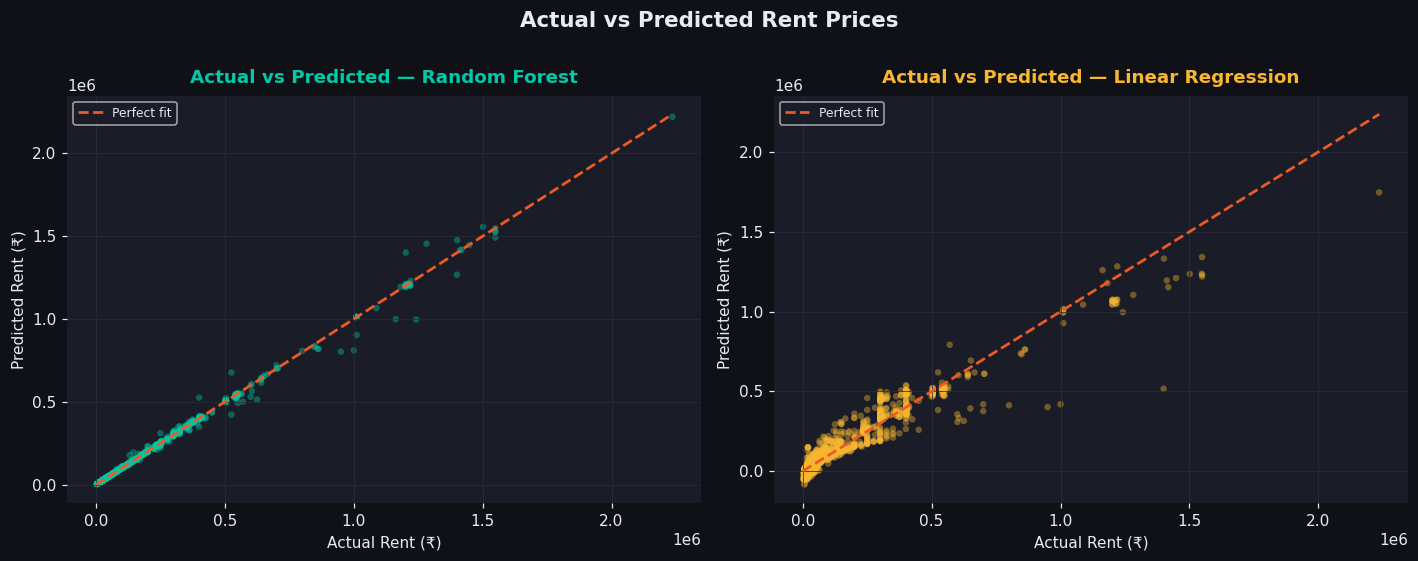

In [306]:
# ── 8.1  Actual vs Predicted ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, label, color in zip(
    axes,
    [rf_preds_test, lr_preds_test],
    ['Random Forest', 'Linear Regression'],
    ['#00c9a7', '#f7b731']
):
    ax.scatter(y_test, preds, alpha=0.4, s=18, color=color, edgecolors='none')
    lim = max(y_test.max(), max(preds))
    ax.plot([0, lim], [0, lim], '--', color='#ee5a24', lw=1.8, label='Perfect fit')
    ax.set_title(f'Actual vs Predicted — {label}', color=color,
                 fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Actual Rent (₹)')
    ax.set_ylabel('Predicted Rent (₹)')
    ax.legend(fontsize=8)
    ax.grid(linewidth=0.5)
    for sp in ax.spines.values(): sp.set_visible(False)

plt.suptitle('Actual vs Predicted Rent Prices', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

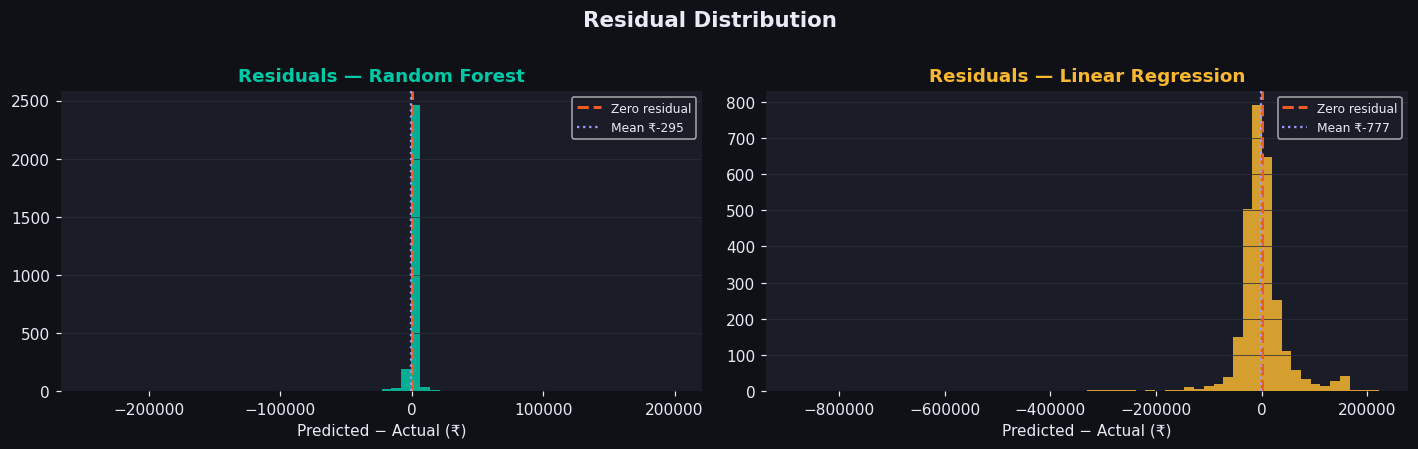

In [307]:
# ── 8.2  Residual Analysis ────────────────────────────────────────────────────
# Good model → residuals centred at 0, roughly bell-shaped
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, res, label, color in zip(
    axes,
    [rf_preds_test - y_test, lr_preds_test - y_test],
    ['Random Forest', 'Linear Regression'],
    ['#00c9a7', '#f7b731']
):
    ax.hist(res, bins=60, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(0,          color='#ee5a24',  lw=2,   ls='--', label='Zero residual')
    ax.axvline(res.mean(), color='#a29bfe',  lw=1.5, ls=':',  label=f'Mean ₹{res.mean():,.0f}')
    ax.set_title(f'Residuals — {label}', color=color, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted − Actual (₹)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linewidth=0.5)
    for sp in ax.spines.values(): sp.set_visible(False)

plt.suptitle('Residual Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [308]:
# ── 8.3  Train vs Test R² (overfitting check) ─────────────────────────────────
overfit_df = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest'],
    'Train R²': [
        round(r2_score(y_train, lr_preds_train), 4),
        round(r2_score(y_train, rf_preds_train), 4)
    ],
    'Test R²':  [
        round(r2_score(y_test, lr_preds_test), 4),
        round(r2_score(y_test, rf_preds_test), 4)
    ]
})
overfit_df['Gap (overfit risk)'] = (overfit_df['Train R²'] - overfit_df['Test R²']).round(4)

print('\n========== OVERFITTING CHECK ==========')
display(overfit_df)
print('\n⚠️  A large gap between Train R² and Test R² indicates overfitting.')
print('   Ideal: gap < 0.05 for generalised predictions.')


========== OVERFITTING CHECK ==========


,Model,Train R²,Test R²,Gap (overfit risk)
0,Linear Regression,0.9268,0.9237,0.0031
1,Random Forest,0.9973,0.9964,0.0009



⚠️  A large gap between Train R² and Test R² indicates overfitting.
   Ideal: gap < 0.05 for generalised predictions.


#9. Price Driver Analysis

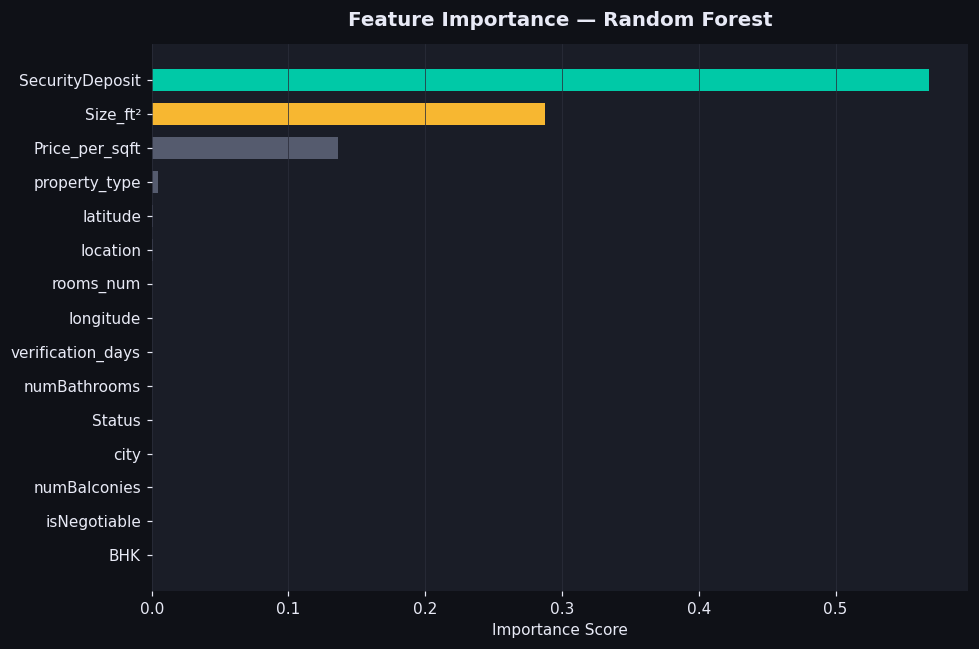

,Feature,Importance,Importance %
0,SecurityDeposit,5.683199e-01,56.83
1,Size_ft²,2.873315e-01,28.73
2,Price_per_sqft,1.361491e-01,13.61
3,property_type,4.736935e-03,0.47
4,latitude,8.451801e-04,0.08
5,location,7.416167e-04,0.07
6,rooms_num,5.826160e-04,0.06
7,longitude,3.995647e-04,0.04
8,verification_days,3.838134e-04,0.04
9,numBathrooms,2.462311e-04,0.02


In [309]:
# ── 9.1  Random Forest Feature Importance ─────────────────────────────────────
feature_names = X_train.columns.tolist()
importances   = rf_model.feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)

colors = ['#00c9a7' if v >= fi.max()*0.6
          else '#f7b731' if v >= fi.max()*0.3
          else '#555b6e'
          for v in fi.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi.index, fi.values, color=colors, edgecolor='none', height=0.65)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest',
             fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='x', linewidth=0.5)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.show()

# Print ranked table
fi_table = fi.sort_values(ascending=False).reset_index()
fi_table.columns = ['Feature', 'Importance']
fi_table['Importance %'] = (fi_table['Importance'] * 100).round(2)
display(fi_table)

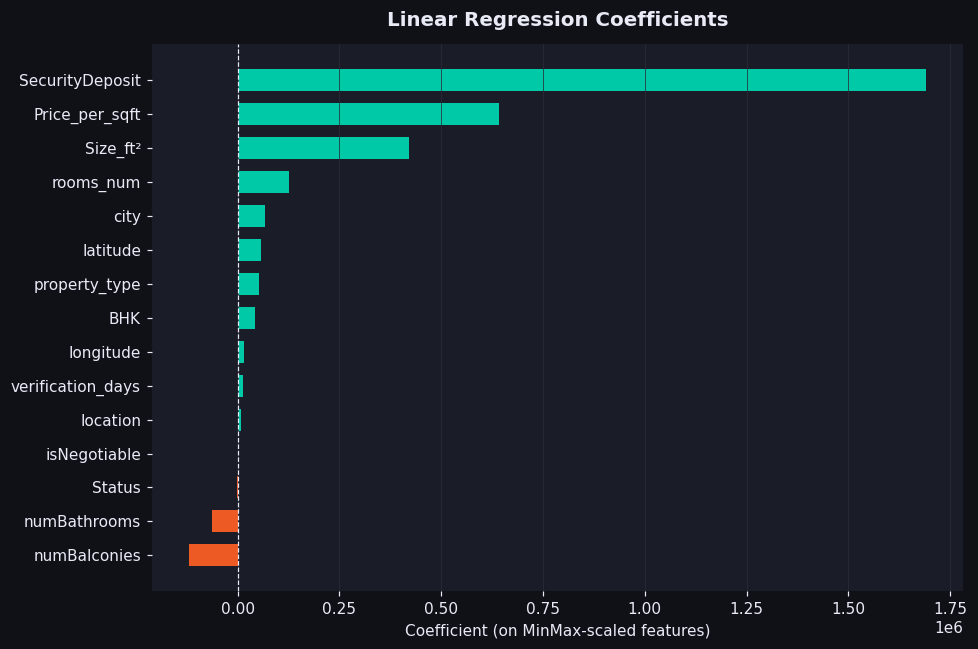

,Feature,Coefficient
0,SecurityDeposit,1.691109e+06
1,Price_per_sqft,6.427547e+05
2,Size_ft²,4.214472e+05
3,rooms_num,1.272743e+05
4,city,6.745705e+04
5,latitude,5.673628e+04
6,property_type,5.310455e+04
7,BHK,4.257684e+04
8,longitude,1.564721e+04
9,verification_days,1.227723e+04


In [310]:
# ── 9.2  Linear Regression Coefficients ──────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=True)

bar_colors = ['#ee5a24' if c < 0 else '#00c9a7' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_df['Feature'], coef_df['Coefficient'],
        color=bar_colors, edgecolor='none', height=0.65)
ax.axvline(0, color='#e8eaf6', lw=0.8, ls='--')
ax.set_xlabel('Coefficient (on MinMax-scaled features)')
ax.set_title('Linear Regression Coefficients',
             fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='x', linewidth=0.5)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.show()

display(coef_df.sort_values('Coefficient', ascending=False).reset_index(drop=True))

#10. Predict Rent for a New Property

In [311]:
def format_inr(value: float) -> str:
    if value >= 1e7:  return f'₹{value/1e7:.2f} Cr'
    if value >= 1e5:  return f'₹{value/1e5:.2f} L'
    return f'₹{value:,.0f}'

def predict_rent(size_sqft, rooms, bathrooms, balconies, bhk_flag,
                 property_type_str, city_str, latitude, longitude,
                 security_deposit, is_negotiable, status_str,
                 location_str, verification_days=5):

    # Encode categorical values
    status = le_status.transform([status_str])[0]
    city = le_city.transform([city_str])[0]
    property_type = le_property.transform([property_type_str])[0]
    location = safe_transform_location(location_str)

    price_per_sqft = 50  # assumed avg (can improve later)

    input_df = pd.DataFrame([{
        'Size_ft²': size_sqft,
        'rooms_num': rooms,
        'numBathrooms': bathrooms,
        'numBalconies': balconies,
        'BHK': bhk_flag,
        'property_type': property_type,
        'city': city,
        'location': location,
        'latitude': latitude,
        'longitude': longitude,
        'SecurityDeposit': security_deposit,
        'isNegotiable': is_negotiable,
        'Status': status,
        'verification_days': verification_days,
        'Price_per_sqft': price_per_sqft
    }])

    input_df = input_df[feature_order]

    # LR needs scaling
    input_scaled = scaler.transform(input_df)

    lr_pred = lr_model.predict(input_scaled)[0]
    rf_pred = rf_model.predict(input_df)[0]
    ensemble = (lr_pred + rf_pred) / 2

    return {
        "Linear Regression": lr_pred,
        "Random Forest": rf_pred,
        "Ensemble Average": ensemble
    }
print('✅ predict_rent() is ready')

✅ predict_rent() is ready


In [312]:
preds = predict_rent(
    size_sqft = 1000,
    rooms = 2,
    bathrooms = 2,
    balconies = 1,
    bhk_flag = 1,
    property_type_str = 'Independent Floor',
    city_str = 'Delhi',
    latitude = 28.6139,
    longitude = 77.2090,
    security_deposit = 25000,
    is_negotiable = 0,
    status_str = 'Furnished',
    location_str = 'Dwarka'
)

print("🏠 2BHK Independent Floor | Delhi")

for model_name, price in preds.items():
    print(f"{model_name}: {format_inr(price)} / month")

ValueError: y contains previously unseen labels: np.int64(662)

In [ ]:
# ── 10.2  Multi-city / multi-config comparison ────────────────────────────────
configs = [
    dict(size_sqft=500,  rooms=1, bathrooms=1, balconies=0, bhk_flag=1,
         property_type_str='Studio Apartment', status_str='Furnished',
         city_str='Mumbai', location_popularity=30, security_deposit=15000, is_negotiable=0),
    dict(size_sqft=1000, rooms=2, bathrooms=2, balconies=1, bhk_flag=1,
         property_type_str='Independent Floor', status_str='Furnished',
         city_str='Delhi', location_popularity=45, security_deposit=25000, is_negotiable=0),
    dict(size_sqft=1500, rooms=3, bathrooms=2, balconies=2, bhk_flag=1,
         property_type_str='Independent House', status_str='Semi-Furnished',
         city_str='Pune', location_popularity=20, security_deposit=40000, is_negotiable=1),
    dict(size_sqft=2000, rooms=4, bathrooms=3, balconies=2, bhk_flag=1,
         property_type_str='Apartment', status_str='Furnished',
         city_str='Mumbai', location_popularity=60, security_deposit=80000, is_negotiable=0),
]

labels = ['1BHK Studio, Mumbai', '2BHK Floor, Delhi',
          '3BHK House, Pune',    '4BHK Apt, Mumbai']

rows = []
for cfg, lbl in zip(configs, labels):
    p = predict_rent(**cfg)
    rows.append({'Property': lbl,
                 'LR Estimate':  format_inr(p['Linear Regression']),
                 'RF Estimate':  format_inr(p['Random Forest']),
                 'Ensemble':     format_inr(p['Ensemble Average'])})

comp_df = pd.DataFrame(rows)
print('\n📋 Multi-Property Rent Estimates')
print('─' * 65)
display(comp_df)